# FIFA World Cup Dataset: Cleaning and Exploratory Data Analysis (EDA)

This notebook contains the analysis, cleaning, and exploratory data analysis of the FIFA World Cup history dataset (`WorldCups.csv`).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set aesthetic styling for plots
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)


## 1. Load the Dataset
We load the raw dataset located at `../DataSet/WorldCups.csv` and inspect the first few records.


In [2]:
# Load the dataset
df = pd.read_csv('../DataSet/WorldCups.csv')
print(f"Dataset Shape: {df.shape}")
df.head()


Dataset Shape: (20, 10)


,Year,Country,Winner,Runners-Up,Third,Fourth,GoalsScored,QualifiedTeams,MatchesPlayed,Attendance
0,1930,Uruguay,Uruguay,Argentina,USA,Yugoslavia,70,13,18,590.549
1,1934,Italy,Italy,Czechoslovakia,Germany,Austria,70,16,17,363.000
2,1938,France,Italy,Hungary,Brazil,Sweden,84,15,18,375.700
3,1950,Brazil,Uruguay,Brazil,Sweden,Spain,88,13,22,1.045.246
4,1954,Switzerland,Germany FR,Hungary,Austria,Uruguay,140,16,26,768.607


## 2. Initial Data Inspection
Let's check the schema, data types, null counts, and check for duplicate entries.


In [3]:
print("--- Dataset Info ---")
df.info()


--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Year            20 non-null     int64 
 1   Country         20 non-null     object
 2   Winner          20 non-null     object
 3   Runners-Up      20 non-null     object
 4   Third           20 non-null     object
 5   Fourth          20 non-null     object
 6   GoalsScored     20 non-null     int64 
 7   QualifiedTeams  20 non-null     int64 
 8   MatchesPlayed   20 non-null     int64 
 9   Attendance      20 non-null     object
dtypes: int64(4), object(6)
memory usage: 1.7+ KB


In [4]:
print("--- Missing Values ---")
print(df.isnull().sum())
print(f"\nDuplicate rows count: {df.duplicated().sum()}")


--- Missing Values ---
Year              0
Country           0
Winner            0
Runners-Up        0
Third             0
Fourth            0
GoalsScored       0
QualifiedTeams    0
MatchesPlayed     0
Attendance        0
dtype: int64

Duplicate rows count: 0


## 3. Data Cleaning
We can identify the following issues in the dataset:
1. **Attendance column**: The values are represented as strings (objects) with dot `.` as a thousands separator (e.g. `1.045.246`). This causes Python to interpret them as objects or floats improperly. We must replace `.` with `""` and cast to `int64`.
2. **Team names standardization**: Strip any leading or trailing whitespaces. Standardize `Germany FR` to `Germany` for historical statistical aggregation.


In [5]:
# 1. Clean the Attendance column
# Convert to string, replace dot with empty string, and convert to integer
df['Attendance'] = df['Attendance'].astype(str).str.replace('.', '', regex=False).astype('int64')

# 2. Clean team names (Winner, Runners-Up, Third, Fourth) and Country column
cols_to_strip = ['Winner', 'Runners-Up', 'Third', 'Fourth', 'Country']
for col in cols_to_strip:
    df[col] = df[col].astype(str).str.strip()
    
# Standardize 'Germany FR' to 'Germany'
# Historically, Germany FR refers to West Germany, which is statistically aggregated under Germany.
for col in ['Winner', 'Runners-Up', 'Third', 'Fourth']:
    df[col] = df[col].replace('Germany FR', 'Germany')

print("Data Types after cleaning:")
df.info()


Data Types after cleaning:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Year            20 non-null     int64 
 1   Country         20 non-null     object
 2   Winner          20 non-null     object
 3   Runners-Up      20 non-null     object
 4   Third           20 non-null     object
 5   Fourth          20 non-null     object
 6   GoalsScored     20 non-null     int64 
 7   QualifiedTeams  20 non-null     int64 
 8   MatchesPlayed   20 non-null     int64 
 9   Attendance      20 non-null     int64 
dtypes: int64(5), object(5)
memory usage: 1.7+ KB


In [6]:
# Display clean head
df.head()


,Year,Country,Winner,Runners-Up,Third,Fourth,GoalsScored,QualifiedTeams,MatchesPlayed,Attendance
0,1930,Uruguay,Uruguay,Argentina,USA,Yugoslavia,70,13,18,590549
1,1934,Italy,Italy,Czechoslovakia,Germany,Austria,70,16,17,363000
2,1938,France,Italy,Hungary,Brazil,Sweden,84,15,18,375700
3,1950,Brazil,Uruguay,Brazil,Sweden,Spain,88,13,22,1045246
4,1954,Switzerland,Germany,Hungary,Austria,Uruguay,140,16,26,768607


## 4. Save Cleaned Dataset
Let's save the cleaned dataset as `WorldCups_cleaned.csv` in the `DataSet` directory.


In [7]:
import os
# Ensure directory exists
os.makedirs('../DataSet', exist_ok=True)
df.to_csv('../DataSet/WorldCups_cleaned.csv', index=False)
print("Cleaned dataset successfully saved to '../DataSet/WorldCups_cleaned.csv'")


Cleaned dataset successfully saved to '../DataSet/WorldCups_cleaned.csv'


## 5. Exploratory Data Analysis (EDA) & Visualizations

Now, let's explore and visualize some trends in the World Cup history!


### 5.1 Distribution of Goals Scored and Matches Played

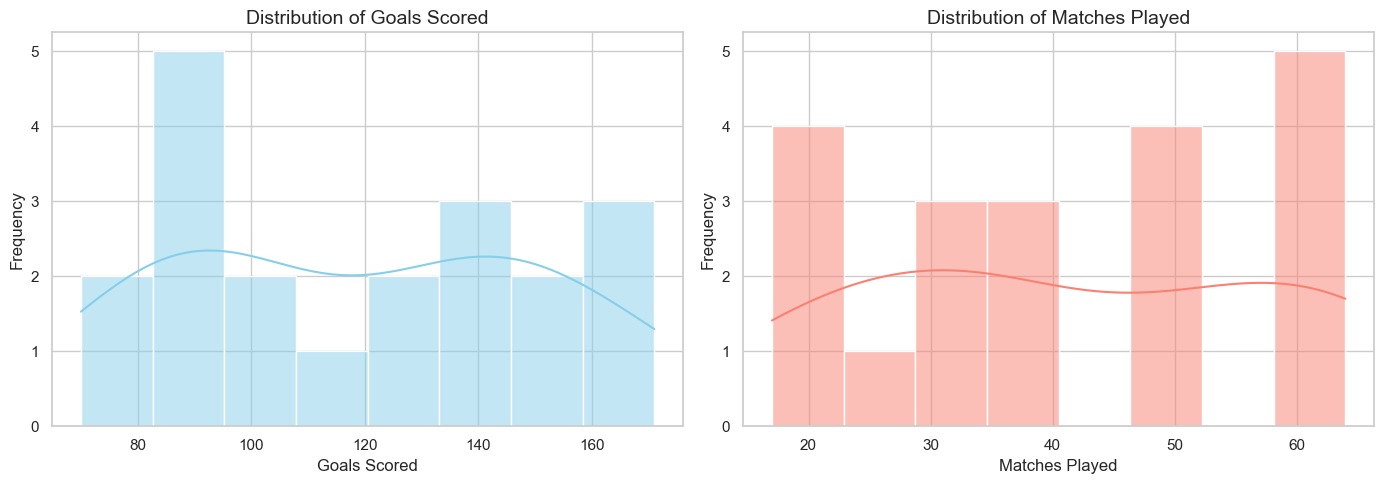

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['GoalsScored'], kde=True, bins=8, color='skyblue', ax=axes[0])
axes[0].set_title('Distribution of Goals Scored', fontsize=14)
axes[0].set_xlabel('Goals Scored')
axes[0].set_ylabel('Frequency')

sns.histplot(df['MatchesPlayed'], kde=True, bins=8, color='salmon', ax=axes[1])
axes[1].set_title('Distribution of Matches Played', fontsize=14)
axes[1].set_xlabel('Matches Played')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()


### 5.2 Most Successful Nations (Winner counts)

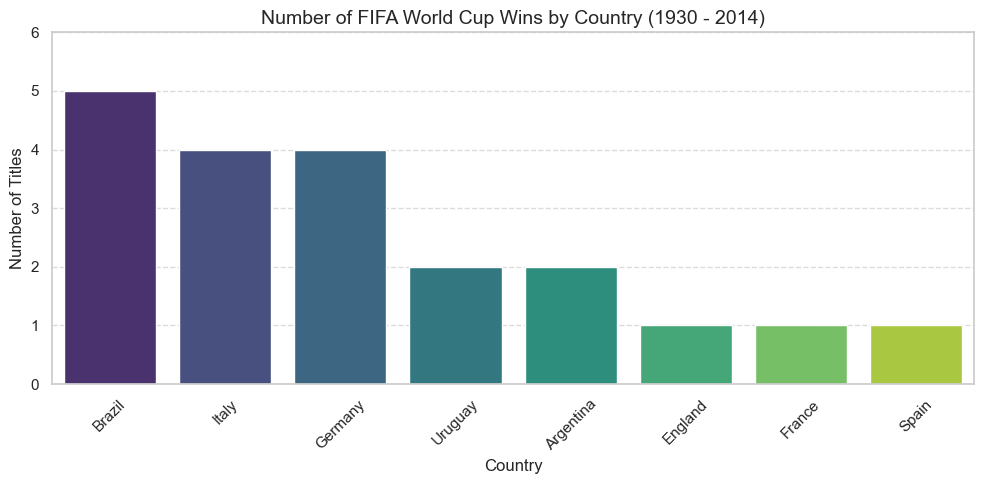

In [9]:
winner_counts = df['Winner'].value_counts()

plt.figure(figsize=(10, 5))
sns.barplot(x=winner_counts.index, y=winner_counts.values, palette='viridis')
plt.title('Number of FIFA World Cup Wins by Country (1930 - 2014)', fontsize=14)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Number of Titles', fontsize=12)
plt.xticks(rotation=45)
plt.yticks(range(0, max(winner_counts.values) + 2))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### 5.3 Trends Over Time: Goals Scored and Attendance

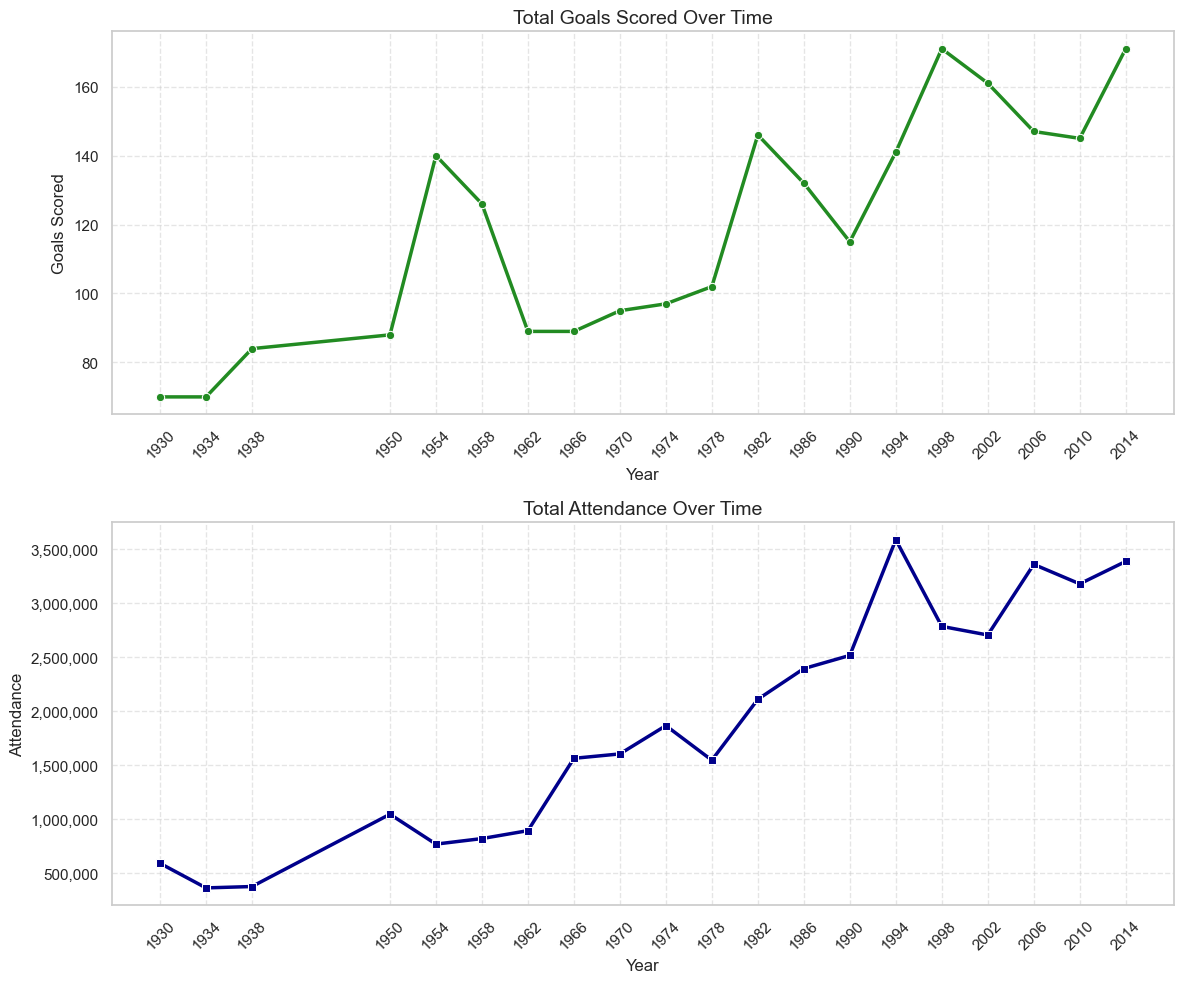

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Goals Scored trend
sns.lineplot(data=df, x='Year', y='GoalsScored', marker='o', color='forestgreen', linewidth=2.5, ax=axes[0])
axes[0].set_title('Total Goals Scored Over Time', fontsize=14)
axes[0].set_xlabel('Year', fontsize=12)
axes[0].set_ylabel('Goals Scored', fontsize=12)
axes[0].set_xticks(df['Year'])
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, linestyle='--', alpha=0.5)

# Attendance trend
sns.lineplot(data=df, x='Year', y='Attendance', marker='s', color='darkblue', linewidth=2.5, ax=axes[1])
axes[1].set_title('Total Attendance Over Time', fontsize=14)
axes[1].set_xlabel('Year', fontsize=12)
axes[1].set_ylabel('Attendance', fontsize=12)
axes[1].get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
axes[1].set_xticks(df['Year'])
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


### 5.4 Correlation Matrix of Numeric Attributes

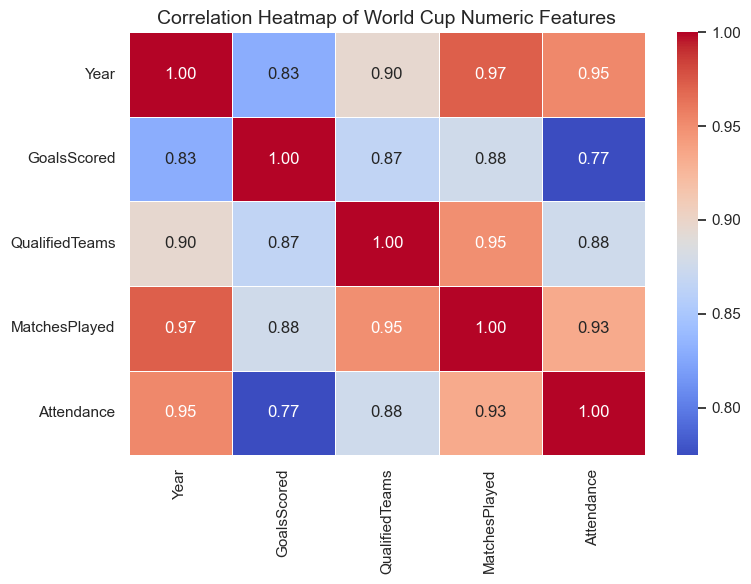

In [11]:
numeric_cols = ['Year', 'GoalsScored', 'QualifiedTeams', 'MatchesPlayed', 'Attendance']
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of World Cup Numeric Features', fontsize=14)
plt.tight_layout()
plt.show()


### 5.5 Relationships: Qualified Teams vs. Goals Scored

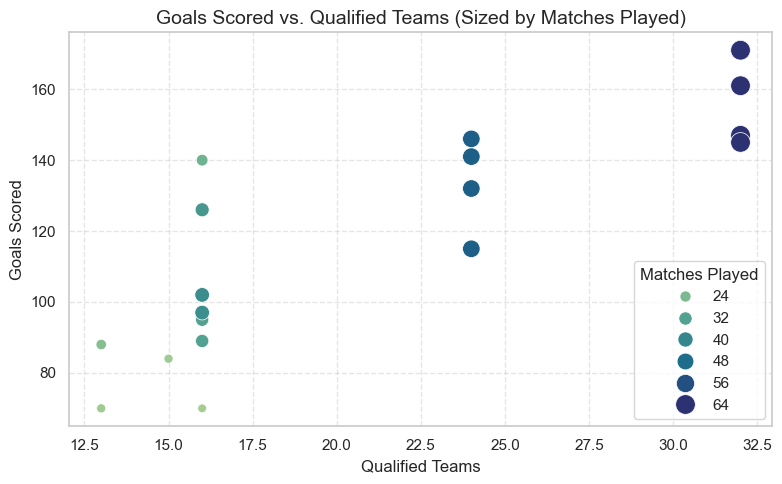

In [12]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='QualifiedTeams', y='GoalsScored', size='MatchesPlayed', hue='MatchesPlayed', palette='crest', sizes=(40, 200))
plt.title('Goals Scored vs. Qualified Teams (Sized by Matches Played)', fontsize=14)
plt.xlabel('Qualified Teams')
plt.ylabel('Goals Scored')
plt.legend(title='Matches Played')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
